In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Backtest — Seasonality / Calendar Effects

Long-term portfolio research: 8 calendar-based strategies, all with ≥30-day holds.

**Strategies tested:**
1. Sell in May / Halloween (SPY ↔ TLT/cash)
2. Best Six Months + MACD timing
3. Presidential cycle (4-year) — *flagged underpowered*
4. January effect (small caps) — 3 variants
5. Q4 seasonality
6. Sector rotation by season (predefined calendar)
7. Month-of-year sector tilt (walk-forward, OOS only)
8. Worst-month avoidance (skip September)

**Defensive instrument:** test both cash and TLT for strategies with defensive leg.

**Validation:** daily mark-to-market equity, bootstrap Sharpe p-value, vs SPY benchmark.

---

## Section 0 — Setup

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

OUT_DIR = Path("./output")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "daily_equity").mkdir(exist_ok=True)
(OUT_DIR / "trades").mkdir(exist_ok=True)

## Section 1 — Data Pull & Validation

**Universe:**
- Core: SPY, TLT, IWM, IJR
- Sectors: XLE, XLK, XLY, XLP, XLU, XLF, XLI, XLV, XLB, XLC

**Inception constraints:**
- SPY: 1993
- TLT: 2002
- IWM: 2000, IJR: 2000
- Sector ETFs (original 9): 1998; XLC: 2018 (excluded from sector seasonal — too short)

Pulling 2003-present aligns sample across all instruments for fair sector comparison.

In [2]:
TICKERS_CORE = ["SPY", "TLT", "IWM", "IJR"]
TICKERS_SECTOR = ["XLE", "XLK", "XLY", "XLP", "XLU", "XLF", "XLI", "XLV", "XLB"]
TICKERS_ALL = TICKERS_CORE + TICKERS_SECTOR

START = datetime(2003, 1, 1)
END = datetime(2025, 5, 1)

raw = fetch_historical_data(TICKERS_ALL, TimeFrame(1, TimeFrameUnit.Day), START, END)

# strip tz, keep close only
data = {}
for tk, df in raw.items():
    df = df.copy()
    df.index = df.index.tz_localize(None) if df.index.tz is not None else df.index
    data[tk] = df

print("Pulled tickers:", list(data.keys()))
print(f"\nDate range observed:")
for tk, df in data.items():
    print(f"  {tk}: {df.index.min().date()} → {df.index.max().date()}  ({len(df)} bars)")

Fetching SPY...
  2,345 bars
Fetching TLT...
  2,345 bars
Fetching IWM...
  2,345 bars
Fetching IJR...
  2,345 bars
Fetching XLE...
  2,345 bars
Fetching XLK...
  2,345 bars
Fetching XLY...
  2,345 bars
Fetching XLP...
  2,345 bars
Fetching XLU...
  2,345 bars
Fetching XLF...
  2,345 bars
Fetching XLI...
  2,345 bars
Fetching XLV...
  2,345 bars
Fetching XLB...
  2,345 bars
Pulled tickers: ['SPY', 'TLT', 'IWM', 'IJR', 'XLE', 'XLK', 'XLY', 'XLP', 'XLU', 'XLF', 'XLI', 'XLV', 'XLB']

Date range observed:
  SPY: 2016-01-04 → 2025-04-30  (2345 bars)
  TLT: 2016-01-04 → 2025-04-30  (2345 bars)
  IWM: 2016-01-04 → 2025-04-30  (2345 bars)
  IJR: 2016-01-04 → 2025-04-30  (2345 bars)
  XLE: 2016-01-04 → 2025-04-30  (2345 bars)
  XLK: 2016-01-04 → 2025-04-30  (2345 bars)
  XLY: 2016-01-04 → 2025-04-30  (2345 bars)
  XLP: 2016-01-04 → 2025-04-30  (2345 bars)
  XLU: 2016-01-04 → 2025-04-30  (2345 bars)
  XLF: 2016-01-04 → 2025-04-30  (2345 bars)
  XLI: 2016-01-04 → 2025-04-30  (2345 bars)
  XLV: 20

In [3]:
# Sanity: gaps, NaNs, business-day alignment
print("=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

for tk, df in data.items():
    nan_count = df["close"].isna().sum()
    bdays_expected = len(pd.bdate_range(df.index.min(), df.index.max()))
    bdays_actual = len(df)
    gap_pct = 100 * (1 - bdays_actual / bdays_expected)
    print(f"{tk:5s} | NaNs: {nan_count:3d} | bars: {bdays_actual:5d} / {bdays_expected:5d} expected  ({gap_pct:+.1f}% gap)")

DATA QUALITY CHECKS
SPY   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
TLT   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
IWM   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
IJR   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLE   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLK   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLY   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLP   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLU   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLF   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLI   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLV   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)
XLB   | NaNs:   0 | bars:  2345 /  2433 expected  (+3.6% gap)


In [4]:
# Build a unified close-price DataFrame (business-day index, ffill small gaps)
bdays = pd.bdate_range(START, END)

px = pd.DataFrame(index=bdays)
for tk, df in data.items():
    s = df["close"].copy()
    s.index = s.index.normalize()
    px[tk] = s.reindex(bdays).ffill(limit=3)

# Trim to first row where SPY has data
first_valid = px["SPY"].first_valid_index()
px = px.loc[first_valid:]

print(f"Unified price frame: {px.index.min().date()} → {px.index.max().date()}")
print(f"Shape: {px.shape}")
px.tail()

Unified price frame: 2016-01-04 → 2025-05-01
Shape: (2434, 13)


,SPY,TLT,IWM,IJR,XLE,XLK,XLY,XLP,XLU,XLF,XLI,XLV,XLB
2025-04-25,544.37,84.72,192.05,98.49,39.91,103.64,98.03,78.66,38.02,47.29,127.30,135.63,40.52
2025-04-28,544.58,85.25,192.86,98.83,40.19,103.47,98.06,78.40,38.26,47.44,127.72,136.17,40.59
2025-04-29,548.01,85.97,194.00,99.48,40.08,103.96,98.75,79.05,38.55,47.93,128.55,136.84,40.93
2025-04-30,548.23,85.27,192.78,98.78,39.00,104.39,97.86,79.63,38.36,48.02,129.48,138.01,41.14
2025-05-01,548.23,85.27,192.78,98.78,39.00,104.39,97.86,79.63,38.36,48.02,129.48,138.01,41.14


In [5]:
# Per-ticker availability after unified reindex
print("First valid date per ticker (after reindex):")
for tk in TICKERS_ALL:
    fv = px[tk].first_valid_index()
    pct_avail = 100 * px[tk].notna().mean()
    print(f"  {tk:5s}: {fv.date() if fv is not None else 'NONE':>12}  ({pct_avail:.1f}% available)")

First valid date per ticker (after reindex):
  SPY  : >12  (100.0% available)
  TLT  : >12  (100.0% available)
  IWM  : >12  (100.0% available)
  IJR  : >12  (100.0% available)
  XLE  : >12  (100.0% available)
  XLK  : >12  (100.0% available)
  XLY  : >12  (100.0% available)
  XLP  : >12  (100.0% available)
  XLU  : >12  (100.0% available)
  XLF  : >12  (100.0% available)
  XLI  : >12  (100.0% available)
  XLV  : >12  (100.0% available)
  XLB  : >12  (100.0% available)


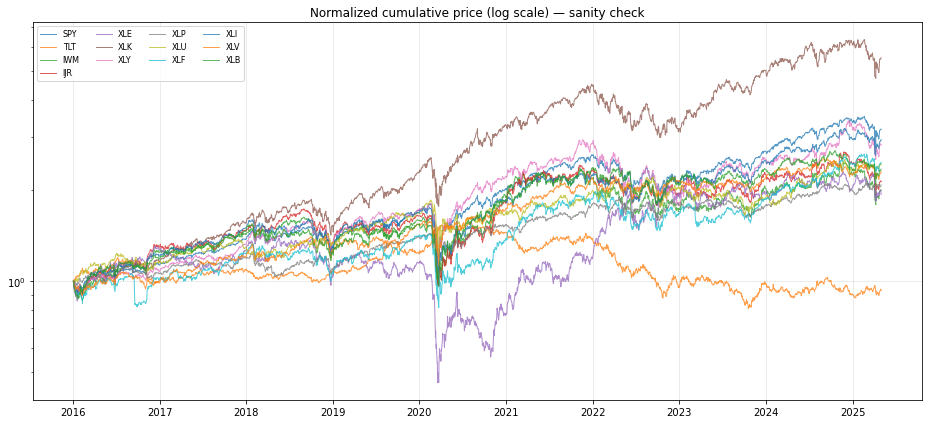

In [7]:
# Quick visual: normalized cumulative returns for all instruments
fig, ax = plt.subplots(figsize=(13, 6))
for tk in TICKERS_ALL:
    s = px[tk].dropna()
    norm = s / s.iloc[0]
    ax.plot(np.asarray(norm.index), np.asarray(norm.values), label=tk, lw=1.0, alpha=0.75)
ax.set_yscale("log")
ax.set_title("Normalized cumulative price (log scale) — sanity check")
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
rets = px.pct_change()

summary = pd.DataFrame({
    "start": [px[tk].first_valid_index().date() for tk in TICKERS_ALL],
    "end": [px[tk].last_valid_index().date() for tk in TICKERS_ALL],
    "bars": [px[tk].notna().sum() for tk in TICKERS_ALL],
    "ann_ret": [(1 + rets[tk].mean()) ** 252 - 1 for tk in TICKERS_ALL],
    "ann_vol": [rets[tk].std() * np.sqrt(252) for tk in TICKERS_ALL],
    "sharpe": [rets[tk].mean() / rets[tk].std() * np.sqrt(252) for tk in TICKERS_ALL],
    "max_dd": [((1 + rets[tk]).cumprod() / (1 + rets[tk]).cumprod().cummax() - 1).min() for tk in TICKERS_ALL],
}, index=TICKERS_ALL)

summary_display = summary.copy()
summary_display["ann_ret"] = summary_display["ann_ret"].map("{:.1%}".format)
summary_display["ann_vol"] = summary_display["ann_vol"].map("{:.1%}".format)
summary_display["sharpe"]  = summary_display["sharpe"].map("{:.2f}".format)
summary_display["max_dd"]  = summary_display["max_dd"].map("{:.1%}".format)
summary_display

,start,end,bars,ann_ret,ann_vol,sharpe,max_dd
SPY,2016-01-04,2025-05-01,2434,14.6%,17.8%,0.77,-33.8%
TLT,2016-01-04,2025-05-01,2434,0.4%,15.0%,0.03,-48.3%
IWM,2016-01-04,2025-05-01,2434,10.3%,22.7%,0.43,-41.3%
IJR,2016-01-04,2025-05-01,2434,11.0%,22.6%,0.46,-44.4%
XLE,2016-01-04,2025-05-01,2434,11.9%,29.6%,0.38,-66.8%
XLK,2016-01-04,2025-05-01,2434,22.9%,24.2%,0.85,-33.6%
XLY,2016-01-04,2025-05-01,2434,14.0%,21.7%,0.61,-39.7%
XLP,2016-01-04,2025-05-01,2434,9.1%,14.9%,0.59,-24.5%
XLU,2016-01-04,2025-05-01,2434,11.7%,18.9%,0.58,-36.1%
XLF,2016-01-04,2025-05-01,2434,12.8%,23.0%,0.53,-42.9%


In [10]:
# Save validated price frame for downstream sections
px.to_parquet(OUT_DIR / "prices_validated.parquet")
print(f"Saved → {OUT_DIR / 'prices_validated.parquet'}")
print(f"Ready for strategy sections (2-9).")

Saved → output\prices_validated.parquet
Ready for strategy sections (2-9).


---

**Checkpoint:** verify the data above looks clean before proceeding to strategy sections.

Things to confirm:
- All tickers loaded with reasonable date ranges (SPY ~1993 if Alpaca permits, sectors ~2003, XLC absent or short)
- No large gaps in `% gap` column
- Annualized returns/Sharpe in expected ballpark (SPY ~0.5 Sharpe, TLT ~0.3, sectors mixed)
- Cumulative price plot shows no obvious data errors (split adjustments, gaps)

Once verified, Sections 2-9 will build each strategy on top of `prices_validated.parquet`.